In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. LOAD AND MERGE ALL PROVIDED DATA
# ==========================================
print("Loading data...")
# Main training data
df_train_main = pd.read_csv('s26-c146-project-training.tsv', sep='\t')
# ARSA experimental data (folded into training to improve gene-specific accuracy)
df_arsa_sample = pd.read_csv('s26-c146-project-cagi-7-arsa-sample.tsv', sep='\t')
# Target variants to predict on
df_target = pd.read_csv('s26-c146-arsa-cagi-snv-features.tsv', sep='\t')
# Final submission template
template = pd.read_csv('s26-c146-arsa-cagi-snv-template.tsv', sep='\t')

# Clean column headers of any hidden whitespace
for df in [df_train_main, df_arsa_sample, df_target]:
    df.columns = df.columns.str.strip()

# Combine main training and ARSA experimental variants
df_train = pd.concat([df_train_main, df_arsa_sample], axis=0, ignore_index=True)

# ==========================================
# 2. MNV DETECTION & FEATURE DEFINITION
# ==========================================
print("Flagging MNVs and defining features...")
def add_mnv_flag(df):
    # Flags as 1 if the reference or alternate sequence is longer than 1 character
    df['is_MNV'] = df.apply(lambda x: 1 if len(str(x['ref'])) > 1 or len(str(x['alt'])) > 1 else 0, axis=1)
    return df

df_train = add_mnv_flag(df_train)
df_target = add_mnv_flag(df_target)

# Define which features need to be inverted (so higher always = pathogenic)
to_invert = ['SIFT_score', 'PROVEAN_score', 'FATHMM_score', 'ESM1b_score']
standard_features = ['Polyphen2_HVAR_score', 'CADD_raw', 'GERP++_RS', 'AlphaMissense_score', 'is_MNV']
all_features = to_invert + standard_features

# Filter down to just our features
X_train = df_train[all_features].copy()
X_target = df_target[all_features].copy()

# ==========================================
# 3. STRICT NUMERIC CLEANING (Fixes ValueErrors)
# ==========================================
print("Cleaning data and handling multiple transcript scores...")
def force_numeric(df_features):
    for col in all_features:
        if col != 'is_MNV':
            # 1. Take only the first value if multiple transcripts are listed (separated by ; or ,)
            df_features[col] = df_features[col].astype(str).str.split(';').str[0].str.split(',').str[0]
            # 2. Force to float. Any remaining strings (like '') become NaN
            df_features[col] = pd.to_numeric(df_features[col], errors='coerce')
    return df_features

X_train = force_numeric(X_train)
X_target = force_numeric(X_target)

# Invert scores
for col in to_invert:
    X_train[col] = X_train[col] * -1
    X_target[col] = X_target[col] * -1

# Clean target labels (1 = Pathogenic, 0 = Benign) and drop rows missing significance
y_train = df_train['Clinical_significance'].map({'Pathogenic': 1, 'Benign': 0})
valid_idx = y_train.dropna().index
X_train, y_train = X_train.loc[valid_idx], y_train.loc[valid_idx]

# ==========================================
# 4. RANDOM FOREST VS K-NN COMPARISON
# ==========================================
print(f"Data ready. Total training variants: {X_train.shape[0]}. Running 5-fold CV Comparison...")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'k-NN': KNeighborsClassifier(n_neighbors=15, weights='distance')
}

comparison_results = []

for name, model in models.items():
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    
    # error_score='raise' ensures any underlying errors surface immediately
    cv_scores = cross_validate(pipe, X_train, y_train, cv=5, scoring='roc_auc', error_score='raise', n_jobs=-1)
    
    # Note: scikit-learn outputs single metrics as 'test_score', not 'test_roc_auc'
    comparison_results.append({
        'Model': name, 
        'Mean CV ROC-AUC': cv_scores['test_score'].mean()
    })

print("\n--- Final Model Comparison ---")
print(pd.DataFrame(comparison_results))
# ==========================================
# 5. FINAL ARSA PREDICTIONS & SUBMISSION
# ==========================================
print("\nTraining final Meta-Predictor on full dataset...")

# Fit the final Random Forest pipeline
final_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])

final_pipe.fit(X_train, y_train)

# Get pathogenicity probabilities (column index 1)
pathogenicity_probs = final_pipe.predict_proba(X_target)[:, 1]

# CAGI 7 requires "Stability" predictions, which is 1 - Pathogenicity
stability_scores = 1 - pathogenicity_probs

# LOAD THE FRESH TEMPLATE
template = pd.read_csv('s26-c146-arsa-cagi-snv-template.tsv', sep='\t')

# Fill the specific stability score column
template['stability_score_48hr'] = stability_scores

# Ensure standard CAGI formatting for empty columns
template['sd'] = '*'
template['comment'] = ''

# Save strictly as a TSV
submission_filename = 's26-c146-arsa-cagi-snv-submission.tsv'
template.to_csv(submission_filename, sep='\t', index=False)

print(f"Final predictions complete! Saved filled template to: '{submission_filename}'")

Loading data...
Flagging MNVs and defining features...
Cleaning data and handling multiple transcript scores...
Data ready. Total training variants: 13464. Running 5-fold CV Comparison...

--- Final Model Comparison ---
           Model  Mean CV ROC-AUC
0  Random Forest         0.940374
1           k-NN         0.912302

Training final Meta-Predictor on full dataset...
Final predictions complete! Saved filled template to: 's26-c146-arsa-cagi-snv-submission.tsv'


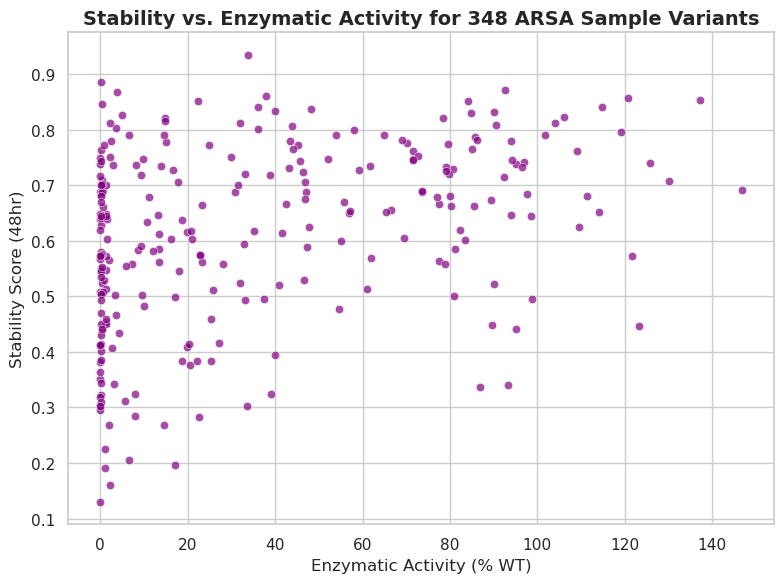

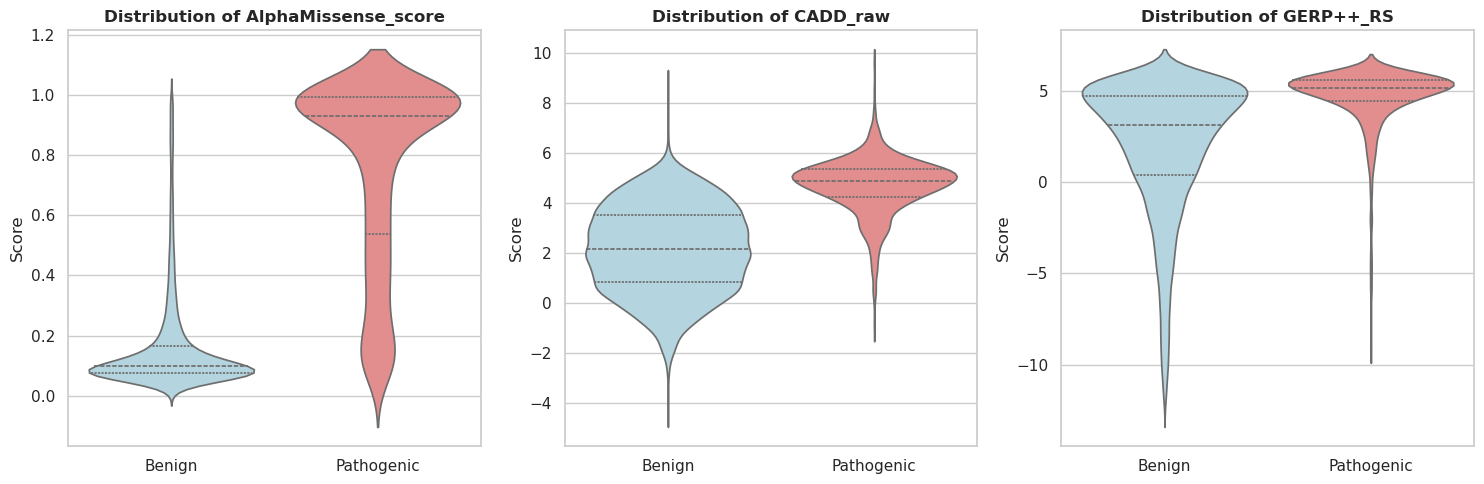

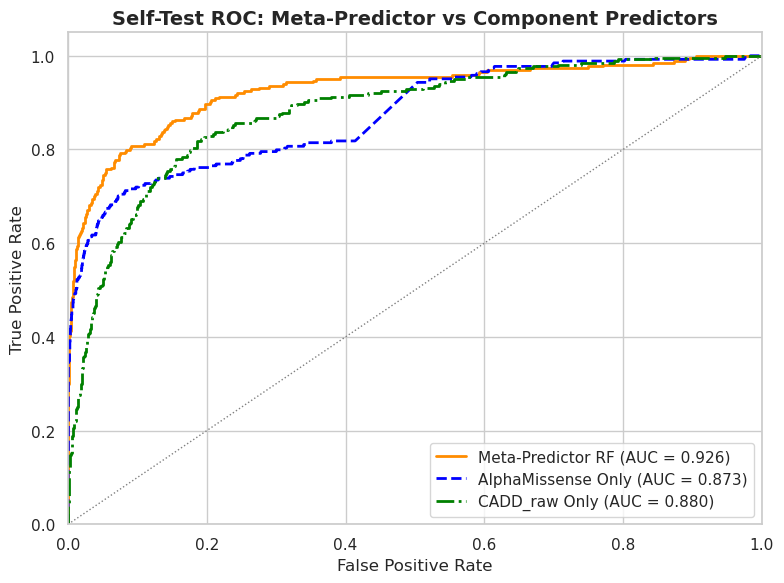

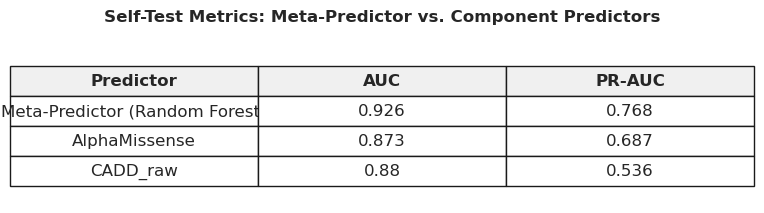

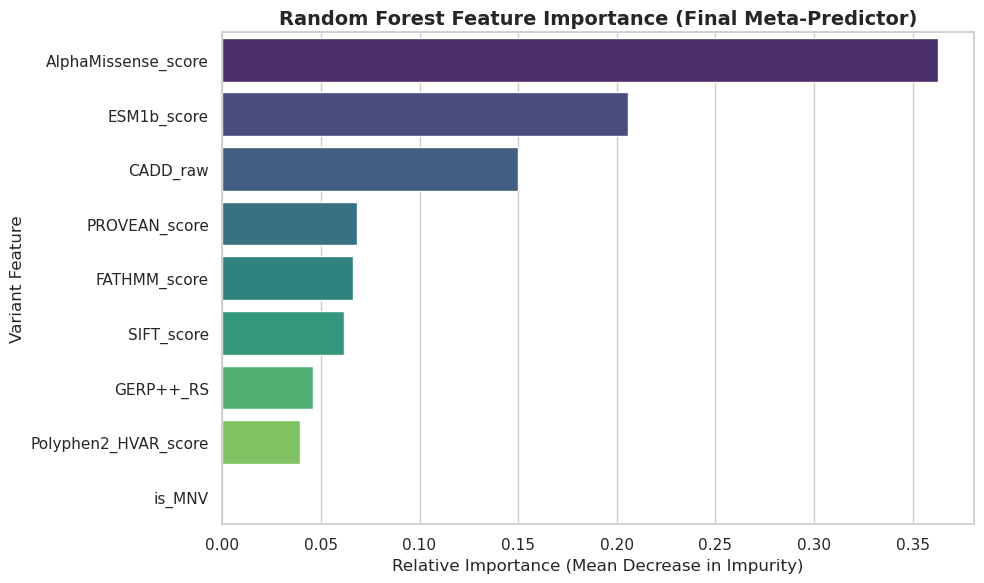

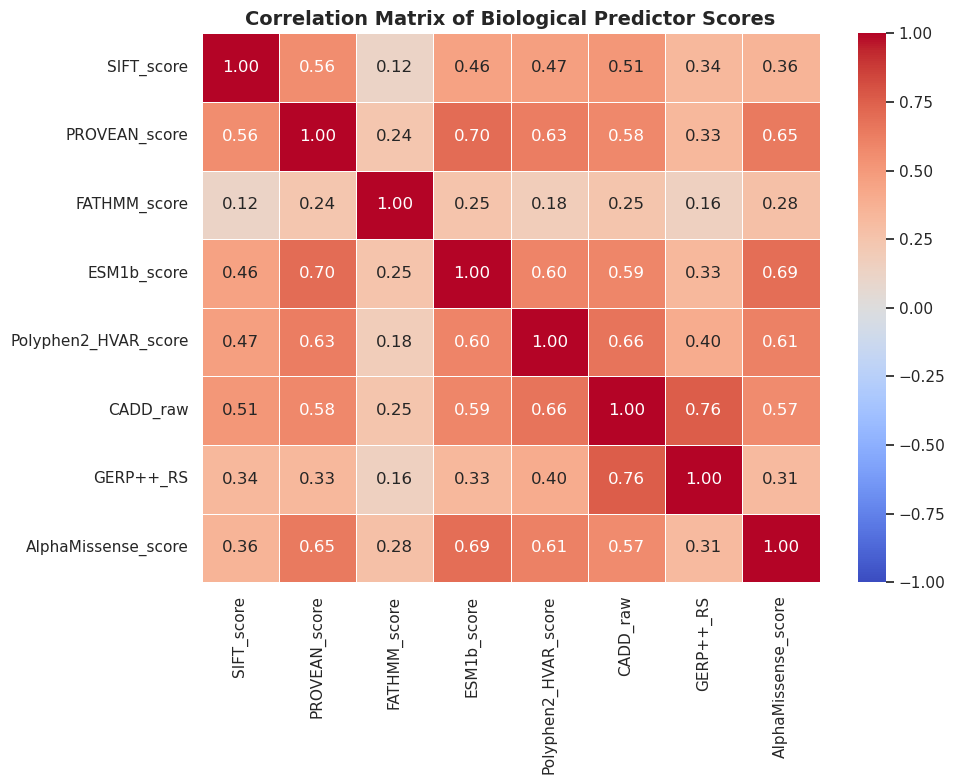

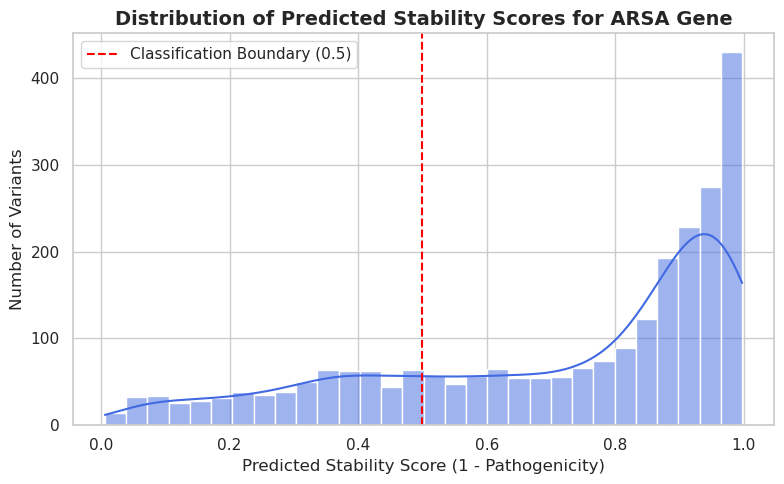

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

# Set a clean, publication-ready visual style
sns.set_theme(style="whitegrid")

# ==========================================
# 0. SETUP: CREATE "SELF-TEST" SET 
# ==========================================
# Split training data into 80% train / 20% self-test to evaluate the meta-predictor
X_train_split, X_self_test, y_train_split, y_self_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Fit a temporary pipeline just on the 80% split to get unbiased self-test predictions
test_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])
test_pipe.fit(X_train_split, y_train_split)

# Meta-predictor probabilities for the self-test set
rf_self_test_probs = test_pipe.predict_proba(X_self_test)[:, 1]


# ==========================================
# 1. STABILITY VERSUS ENZYMATIC ACTIVITY
# ==========================================
# Updated with the exact column names from your dataframe
col_stability = 'stability_score_48hr' 
col_activity = 'CDS percent WT activity'    

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_arsa_sample, x=col_activity, y=col_stability, alpha=0.7, color='purple')

# Add titles and labels
plt.title('Stability vs. Enzymatic Activity for 348 ARSA Sample Variants', fontsize=14, weight='bold')
plt.xlabel('Enzymatic Activity (% WT)', fontsize=12)
plt.ylabel('Stability Score (48hr)', fontsize=12)
plt.tight_layout()

# Save and display
plt.savefig('fig1_stability_vs_activity.png', dpi=300)
plt.show()
# ==========================================
# 2. TRAINING-SET SCORE DISTRIBUTIONS
# ==========================================
# We'll plot 3 component scores. We need to attach the true labels back for plotting.
df_plot = X_train.copy()
df_plot['Clinical_significance'] = y_train.map({1: 'Pathogenic', 0: 'Benign'})

features_to_plot = ['AlphaMissense_score', 'CADD_raw', 'GERP++_RS']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    # The fix: added 'hue' and 'legend=False'
    sns.violinplot(data=df_plot, x='Clinical_significance', y=feature, 
                   hue='Clinical_significance',
                   palette={'Pathogenic': 'lightcoral', 'Benign': 'lightblue'},
                   inner="quartile", legend=False)
    plt.title(f'Distribution of {feature}', weight='bold')
    plt.xlabel('')
    plt.ylabel('Score')

plt.tight_layout()
plt.savefig('fig2_score_distributions.png', dpi=300)
plt.show()

# ==========================================
# 3. SELF-TEST ROC CURVES
# ==========================================
plt.figure(figsize=(8, 6))

# A. Meta-Predictor (Random Forest) ROC
fpr_rf, tpr_rf, _ = roc_curve(y_self_test, rf_self_test_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Meta-Predictor RF (AUC = {roc_auc_rf:.3f})')

# B. Component Predictor 1: AlphaMissense (Raw Score)
# Missing values need to be dropped or filled for roc calculation; we'll fill with median
am_scores = X_self_test['AlphaMissense_score'].fillna(X_self_test['AlphaMissense_score'].median())
fpr_am, tpr_am, _ = roc_curve(y_self_test, am_scores)
plt.plot(fpr_am, tpr_am, color='blue', lw=2, linestyle='--', label=f'AlphaMissense Only (AUC = {auc(fpr_am, tpr_am):.3f})')

# C. Component Predictor 2: CADD_raw (Raw Score)
cadd_scores = X_self_test['CADD_raw'].fillna(X_self_test['CADD_raw'].median())
fpr_cadd, tpr_cadd, _ = roc_curve(y_self_test, cadd_scores)
plt.plot(fpr_cadd, tpr_cadd, color='green', lw=2, linestyle='-.', label=f'CADD_raw Only (AUC = {auc(fpr_cadd, tpr_cadd):.3f})')

# Plot styling
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Self-Test ROC: Meta-Predictor vs Component Predictors', fontsize=14, weight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('fig3_selftest_roc.png', dpi=300)
plt.show()

# ==========================================
# 4. SELF-TEST METRIC TABLE
# ==========================================
# Create a blank figure 
fig, ax = plt.subplots(figsize=(8, 2)) 

# Hide the standard graph axes
ax.axis('tight')
ax.axis('off')

# Render the dataframe as a visual table
table = ax.table(cellText=metrics_df.values, 
                 colLabels=metrics_df.columns, 
                 loc='center', 
                 cellLoc='center')

# Style it to look professional
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8) # Makes the rows a bit taller for readability

# Add a light gray background and bold text to the header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f0f0f0')

# Add a title
plt.title('Self-Test Metrics: Meta-Predictor vs. Component Predictors', weight='bold', pad=20)

# Save as a high-resolution PNG
plt.savefig('fig4_self_test_metric_table.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE (From final_pipe)
# ==========================================
rf_final_model = final_pipe.named_steps['clf']
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance (Final Meta-Predictor)', fontsize=14, weight='bold')
plt.xlabel('Relative Importance (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Variant Feature', fontsize=12)
plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=300)
plt.show()

# ==========================================
# 6. CREATIVE FIGURE: Feature Correlation Heatmap
# ==========================================
# Shows how strongly the different component predictors correlate with each other
plt.figure(figsize=(10, 8))
# Calculate correlations (drop MNV flag as it's binary and skews visuals)
corr_matrix = X_train.drop(columns=['is_MNV']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Biological Predictor Scores', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=300)
plt.show()

# ==========================================
# 7. ARSA PREDICTIONS DISTRIBUTION
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(stability_scores, bins=30, kde=True, color='royalblue')
plt.title('Distribution of Predicted Stability Scores for ARSA Gene', fontsize=14, weight='bold')
plt.xlabel('Predicted Stability Score (1 - Pathogenicity)', fontsize=12)
plt.ylabel('Number of Variants', fontsize=12)
plt.axvline(x=0.5, color='red', linestyle='--', label='Classification Boundary (0.5)')
plt.legend()
plt.tight_layout()
plt.savefig('fig6_arsa_predictions_histogram.png', dpi=300)
plt.show()

In [2]:
!python s26-c146-arsa-cagi-snv-validation.py s26-c146-arsa-cagi-snv-submission.tsv s26-c146-arsa-cagi-snv-template.tsv

Expected variants: 2491
Submitted variants: 2491
Missing variants: 0
Warnings: 0
Errors: 0

The file's format is valid and complete! You are good to submit now!
